### shuffle



In [1]:
from util import fisherztrans,stat_m_e,pair_test,sig,color_inv_alpha,paired_ttest_full
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from faceprf_figure_function import set_figure,set_ax,myviolinplot_ind,myviolinplot_pair
import warnings

cms=np.array([[255, 195, 73],[145, 115, 185]])/255 

# 
nsubj = 8
npos = 16
task = ['Digit Task','Face Task']
roi_labels = ['V1','V2','V3','hV4','IOG','pFus','mFus']
nroi = len(roi_labels)
ntask = len(task)
# distance: near vs. far
num_nf=[[0,4],[5,9]]
nf = ['Near','Far']
# roi: early visual cortex (V1-V3) - face-selective region
num_vf=[[0,3],[4,7]]
vf = ['V1-V3','OFA,FFA-1,FFA-2']
nsample2 = nsubj * np.max(np.diff(num_nf)) * np.max(np.diff(num_vf))
nvertex = 100

ds0 = 2 # degree
ds_list = np.zeros((npos,npos))
for s1 in range(npos):
    r1 = s1//4
    c1 = s1%4
    for s2 in range(s1):
        r2 = s2//4
        c2 = s2%4
        ds_list[s1,s2] = ((r1-r2)**2+(c1-c2)**2)**0.5*ds0
d = np.unique(ds_list)[1:]

data_path = "../data/"

### LFI

In [2]:
task_types = ['fixation','face']
sfl_types = ['ori','sfld']

# load data
lfi_nf_subj = np.zeros([4*nsubj,len(roi_labels),len(sfl_types),len(task_types),len(nf)])*np.nan # 4*8samples x roi x shuffle_type x task x nf
for task_i in range(2):
    lfi_d_subj = np.zeros((len(d),nsubj,len(roi_labels),len(sfl_types)))*np.nan # d x subj x roi x task
    for sfl_i in range(2):
        lfi_ij = np.load('../data/lfi-bc_shuffle_'+sfl_types[sfl_i]+'_'+task_types[task_i]+'.npz',allow_pickle=True)['lfi_ij']
        for dd in range(len(d)):
            lfi_d_subj[dd,:,:,sfl_i] = np.nanmean(np.nanmean(lfi_ij[:,ds_list==d[dd],:,:],axis=1),axis=0)

    # average lfi for near/far distance [4x8]
    nf = ['Near','Far'];num_nf=[[0,4],[5,9]]
    for sfl_i in range(len(sfl_types)):
        for roi_i in range(len(roi_labels)):
            for nf_i in range(len(num_nf)):
                data = lfi_d_subj[num_nf[nf_i][0]:num_nf[nf_i][1],:,roi_i,sfl_i]
                lfi_nf_subj[:,roi_i,sfl_i,task_i,nf_i] = data.reshape([data.shape[0]*data.shape[1]])


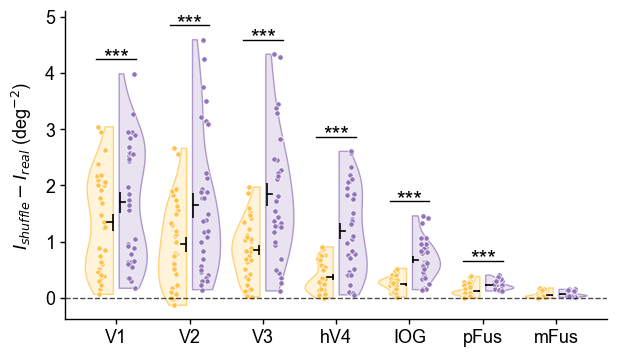

In [ ]:
# plot figure
set_figure()
fig,ax = plt.subplots(1,1,figsize=(7,4),gridspec_kw={'wspace': 0.2})
ylims = [[0.48,1,0.2],[0.48,1,0.2]]

cms=[[255, 195, 73],[145, 115, 185]] # 黄、紫

#for nf_i in range(len(nf)): #near far

nf_i = 1 # far

lfi_diff = np.diff(lfi_nf_subj[:,:,:,:,nf_i],axis=2).squeeze()
ps,_ = pair_test(lfi_diff,method='wilcoxon',correction='bonferroni')

#ax = axes[nf_i]
set_ax(ax)    
# baseline
ax.axhline(y=0, xmin=0, xmax=1, linestyle='--', linewidth=1, alpha=0.7, color='k')
# violinplot
lfi_diff = np.diff(lfi_nf_subj[:,:,:,:,nf_i],axis=2).squeeze() # sample x roi x task
myviolinplot_pair(ax,lfi_diff,'mean','sem',ps,[])

# axis
ax.set_ylabel('$I_{shuffle} - I_{real}$ (deg$^{-2}$)',labelpad=8)
ax.set_xticklabels(roi_labels)
ax.set_xlim([0.3,7.7])
#ax.set_ylim([-0.25,0.25])
#ax.set_title(nf[nf_i],pad=20,fontsize=20)

fig.set_tight_layout(False)
fig.savefig('figures/figS7-lfi-diff.pdf')

In [4]:
# statistical tests: UNATT VS. ATT
# t-test: DIFF(shuffled-orignal) task effect
for nf_i in range(len(nf)):
    df = pd.DataFrame([])
    for roi_i in range(len(roi_labels)):
        lfi_diff = np.diff(lfi_nf_subj[:,roi_i,:,:,nf_i],axis=1).squeeze() # sample x task
        res = paired_ttest_full(lfi_diff[:,0],lfi_diff[:,1],'wilcoxon') # unatt vs. att
        pd.set_option('display.precision', 3)
        print(f'{roi_labels[roi_i]},{nf[nf_i]}:')
        print(res)
        print()
        

V1,Near:
   mean_diff     W          p    RBC  mean1    SE1  mean2    SE2
0     -1.253  32.0  1.288e-06 -0.879  6.641  0.572  7.893  0.681

V2,Near:
   mean_diff     W          p    RBC  mean1    SE1  mean2    SE2
0     -1.409  31.0  1.106e-06 -0.883  4.875  0.642  6.284  0.753

V3,Near:
   mean_diff     W          p    RBC  mean1    SE1  mean2    SE2
0     -1.082  57.0  3.175e-05 -0.784  5.014  0.405  6.096  0.467

hV4,Near:
   mean_diff    W          p    RBC  mean1    SE1  mean2    SE2
0     -0.817  5.0  4.657e-09 -0.981   1.82  0.274  2.637  0.296

IOG,Near:
   mean_diff     W          p    RBC  mean1    SE1  mean2    SE2
0      1.249  31.0  1.106e-06  0.883   2.89  0.436  1.641  0.191

pFus,Near:
   mean_diff    W          p  RBC  mean1    SE1  mean2   SE2
0      1.496  0.0  4.657e-10  1.0  2.088  0.262  0.592  0.05

mFus,Near:
   mean_diff    W          p  RBC  mean1   SE1  mean2    SE2
0      0.663  0.0  4.657e-10  1.0  0.904  0.15   0.24  0.023

V1,Far:
   mean_diff     W      